<a href="https://colab.research.google.com/github/Rakesh-025/Transformers/blob/main/Transformer_based_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Encoder Only models

# Encoder Only models

In [ ]:
from transformers import BertTokenizer, BertModel
import torch

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
inputs = tokenizer("Transformers are powerful", return_tensors = 'pt')

In [ ]:
model= BertModel.from_pretrained('bert-base-uncased')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
outputs = model(**inputs)

In [ ]:
outputs.last_hidden_state.shape

torch.Size([1, 5, 768])

#Decoder Models only

In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

In [ ]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
model = GPT2LMHeadModel.from_pretrained('gpt2')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
input_ids = tokenizer("once upon a time, ", return_tensors = 'pt').input_ids

In [ ]:
output = model.generate(input_ids, max_length = 20, do_sample = True )

In [ ]:
output

tensor([[27078,  2402,   257,   640,    11,   220,  1849,  1026,  4962,   503,
           326,   340,   338,   407,   257,  5434,    11,   780,   772,   996]])

In [ ]:
print(tokenizer.decode(output[0]))

once upon a time,  It turns out that it's not a bug, because even though


#Encoder Decoder model

In [ ]:
from transformers import T5Tokenizer,T5ForConditionalGeneration

In [ ]:
model = T5ForConditionalGeneration.from_pretrained('t5-small')


In [ ]:
tokenizer = T5Tokenizer.from_pretrained('t5-small')

In [ ]:
input_text = """In today's fast-changing world, students must adopt a mindset of continuous learning. New technologies, shifting industries, and global economic changes mean that knowledge can become outdated quickly. Focusing on lifelong learning equips students with the skills to adapt and remain competitive, no matter how rapidly the world changes. By continuously developing their knowledge and abilities, students can improve their career opportunities, solve problems more effectively, and confidently face new challenges. Lifelong learning is therefore essential for personal growth and professional success."""

In [ ]:
input_ids = tokenizer(input_text, return_tensors = 'pt').input_ids

In [ ]:
output = model.generate(input_ids)

/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=119) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


In [ ]:
print(tokenizer.decode(output[0], skip_special_tokens = True) )

In today's fast-changing world, students must adopt a mindset of continuous learning. New technologies, shifting industries, and global economic changes mean that knowledge can become outdated quickly. Focusing on lifelong learning equips students with the skills to adapt and remain competitive, no matter how rapidly the world changes. By continuously developing their knowledge and abilities, students can improve their career opportunities, solve problems more effectively, and confidently face new challenges. Lifelong learning is therefore essential for personal growth and professional success.

Learn more about the benefits of learning.


#LLM_TOPIC_MODELLING

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"

df = pd.read_csv(url, header=None)

In [ ]:
texts = df[1].tolist()[:1000]

In [ ]:
# steps 2 : Get sentence Embeddings using Sentence - Bert

from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2') # bert-base-nli-mean-tokens
embeddings = model.encode(texts, show_progress_bar =  True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
# step 3 : Reduce Dimensions for clustering  (Optional but helpful)
from sklearn.decomposition import PCA

pca = PCA(n_components= 50)
reduced_embeddings = pca.fit_transform(embeddings)

In [ ]:
# Step 4 :  Cluster using HDBSCAN
import  hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size = 15)
clusteres = clusterer.fit_predict(reduced_embeddings)

In [ ]:
# Step 5 : Visualize the UMAP

import umap.umap_ as umap
umap_model = umap.UMAP(n_neighbors = 15, n_components = 2, metric = 'cosine')
umap_embeddings = umap_model.fit_transform(reduced_embeddings)

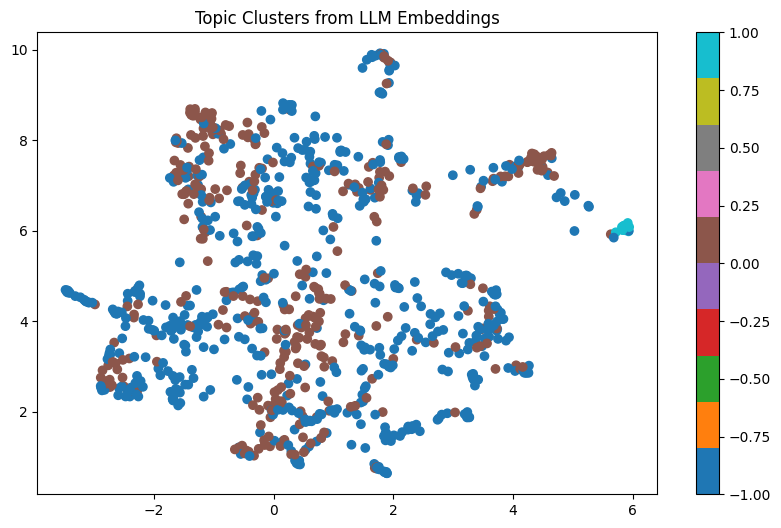

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,6))

plt.scatter(umap_embeddings[:,0], umap_embeddings[:,1], c = clusteres, cmap = 'tab10')
plt.colorbar()
plt.title("Topic Clusters from LLM Embeddings")
plt.show()


In [ ]:
# auto topic modelling

# !pip install bertopic

from bertopic import BERTopic
from datasets import load_dataset
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.4 MB/s eta 0:00:00


In [ ]:
topic_model = BERTopic()
topics, probs = topic_model.fit_transform( texts)

# visualize topics

topic_model.visualize_topics()

NameError: name 'BERTopic' is not defined

#Semantic Search

In [ ]:
!pip install sentence-transformers faiss-cpu scikit-learn gradio pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 48.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd

data = [
    {"query": "What is a patent?", "doc": "A patent is an exclusive right granted for an invention."},
    {"query": "How do I apply for a patent?", "doc": "To apply for a patent, submit an application to the national patent office."},
    {"query": "What does a trademark protect?", "doc": "A trademark protects brand names and logos used on goods and services."},
    {"query": "What is copyright?", "doc": "Copyright protects original works of authorship like books and music."},
    {"query": "What is the duration of a patent?", "doc": "Patents generally last for 20 years from the filing date."},
    {"query": "Can a patent be renewed?", "doc": "Patents cannot usually be renewed beyond their maximum term."},
    {"query": "What happens after a patent expires?", "doc": "After a patent expires, the invention becomes public domain."},
    {"query": "How to challenge a trademark?", "doc": "Trademark opposition is a legal process to prevent registration of a similar mark."},
    {"query": "Who grants patents in the USA?", "doc": "The United States Patent and Trademark Office (USPTO) grants patents."},
    {"query": "What is infringement of copyright?", "doc": "Using copyrighted work without permission may be considered infringement."}
]

df = pd.DataFrame(data)
df.head()


,query,doc
0,What is a patent?,A patent is an exclusive right granted for an ...
1,How do I apply for a patent?,"To apply for a patent, submit an application t..."
2,What does a trademark protect?,A trademark protects brand names and logos use...
3,What is copyright?,Copyright protects original works of authorshi...
4,What is the duration of a patent?,Patents generally last for 20 years from the f...


In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2') #original model

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
doc_embeddings = model.encode(df['doc'].tolist(), show_progress_bar=True)
dimension = doc_embeddings.shape[1]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
index = faiss.IndexFlatL2(dimension)
index.add(doc_embeddings)

In [ ]:
def semantic_search(query, top_k=3):
    query_embedding = model.encode([query])
    D, I = index.search(np.array(query_embedding), k=top_k)
    return df.iloc[I[0]][['doc']]

In [ ]:
semantic_search("Tell me about patent")

,doc
0,A patent is an exclusive right granted for an ...
8,The United States Patent and Trademark Office ...
6,"After a patent expires, the invention becomes ..."


In [ ]:
#fine tuned model
from sentence_transformers import InputExample, losses
from torch.utils.data import DataLoader

/tmp/ipykernel_962/1190538141.py:2: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import InputExample, losses


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./output",
    report_to="none",  # disables wandb, tensorboard, etc.
)

In [ ]:
import os

# Make sure no wandb logs start
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
train_examples = [
    InputExample(texts=["What is a patent?", "A patent is an exclusive right granted for an invention."], label=1),
    InputExample(texts=["How to apply for a patent?", "To apply for a patent, submit an application to the national patent office."], label=1),
    InputExample(texts=["What is copyright?", "Photosynthesis is a process used by plants."], label=0),  # Negative
    InputExample(texts=["What is trademark?", "Trademark protects brand identity"], label=1),
]

In [ ]:
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=2)
train_loss = losses.CosineSimilarityLoss(model)

In [ ]:
model.fit(train_objectives=[(train_dataloader, train_loss)], epochs=1, show_progress_bar=True)
model.save("fine-tuned-legal-sbert")

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
model = SentenceTransformer("fine-tuned-legal-sbert")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
doc_embeddings = model.encode(df['doc'].tolist(), show_progress_bar=True)
index = faiss.IndexFlatL2(doc_embeddings.shape[1])
index.add(doc_embeddings)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
semantic_search("What to do after my patent expired?")

,doc
6,"After a patent expires, the invention becomes ..."
4,Patents generally last for 20 years from the f...
0,A patent is an exclusive right granted for an ...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['doc'].tolist())

def get_tfidf_score(query):
    query_tfidf = vectorizer.transform([query])
    return tfidf_matrix.dot(query_tfidf.T).toarray().flatten()

In [ ]:
def hybrid_search(query, alpha=0.5, top_k=3):
    query_embedding = model.encode([query])
    D, I = index.search(np.array(query_embedding), k=top_k)

    sem_scores = [1 - D[0][i] for i in range(top_k)]  # 1 - L2 distance
    keyword_scores = get_tfidf_score(query)

    results = []
    for rank, idx in enumerate(I[0]):
        final_score = alpha * sem_scores[rank] + (1 - alpha) * keyword_scores[idx]
        results.append((df.iloc[idx]['doc'], final_score))

    return sorted(results, key=lambda x: -x[1])


In [ ]:
for doc, score in hybrid_search("What to do after my patent expired?"):
    print(f"{round(score, 3)} -> {doc}")


0.256 -> After a patent expires, the invention becomes public domain.
0.008 -> A patent is an exclusive right granted for an invention.
-0.019 -> Patents generally last for 20 years from the filing date.


In [ ]:
import gradio as gr

def search_interface(query, alpha=0.5):
    results = hybrid_search(query, alpha)
    return "\n\n".join([f"{doc} (Score: {round(score, 3)})" for doc, score in results])

gr.Interface(
    fn=search_interface,
    inputs=[gr.Textbox(label="Search Query"), gr.Slider(0, 1, value=0.5, label="Semantic vs Keyword Weight")],
    outputs="text",
    title="Domain-Aware Hybrid Search (Legal)"
).launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://63b104929a80cbe8b0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
